# CCB Relative Dose Plot: MC vs EBT3 vs MBO

This notebook loads CCB profiles, aligns them horizontally using the **distal 90% falloff point** while keeping **MC as the reference**, and rescales every profile so that its maximum equals **1.0**.

Color convention:
- **MC** in **black**
- **EBT3** in **red**
- **MBO** in **green**

The figure uses larger fonts for presentation and publication readability.

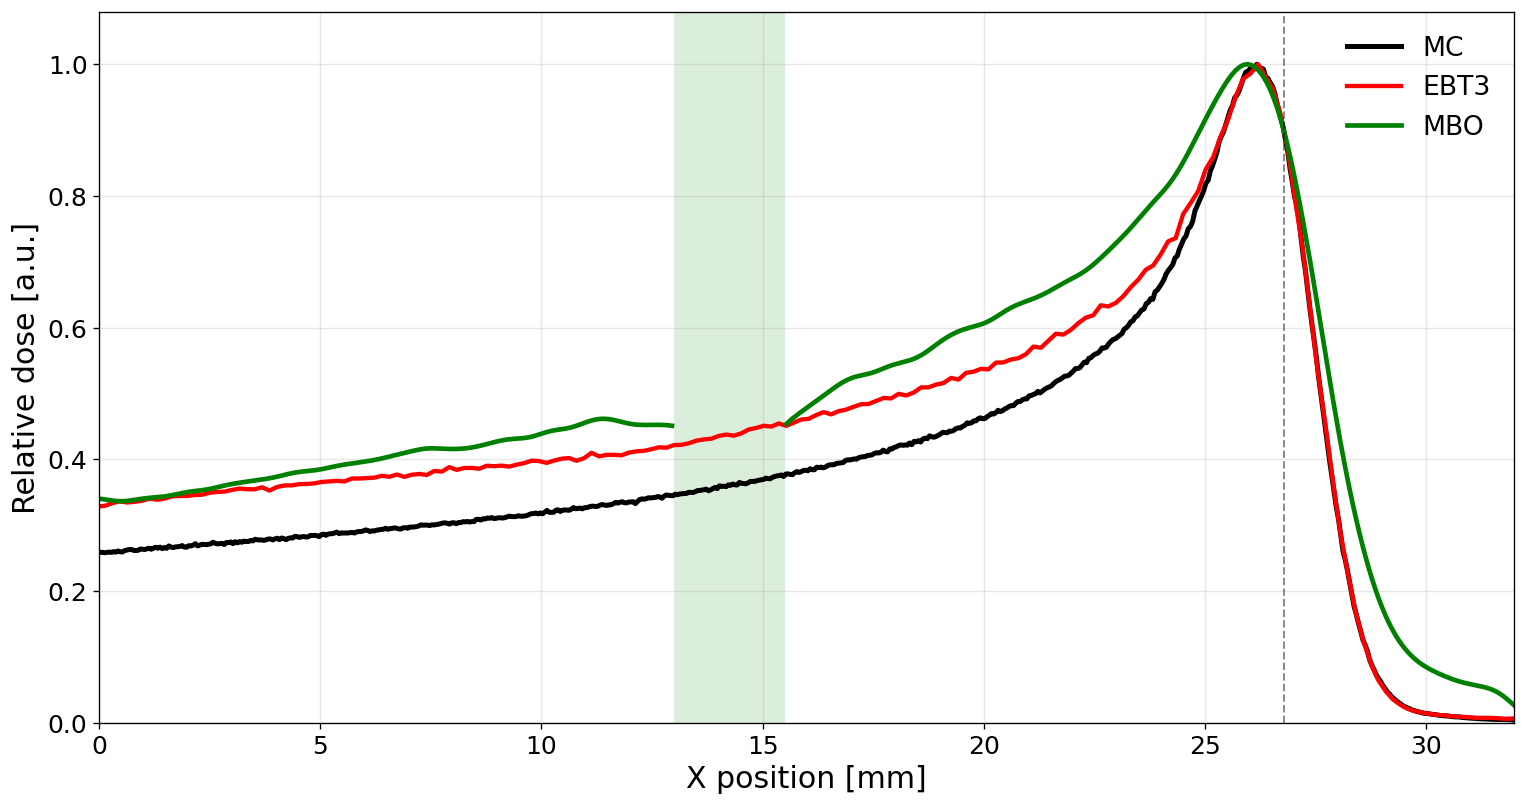

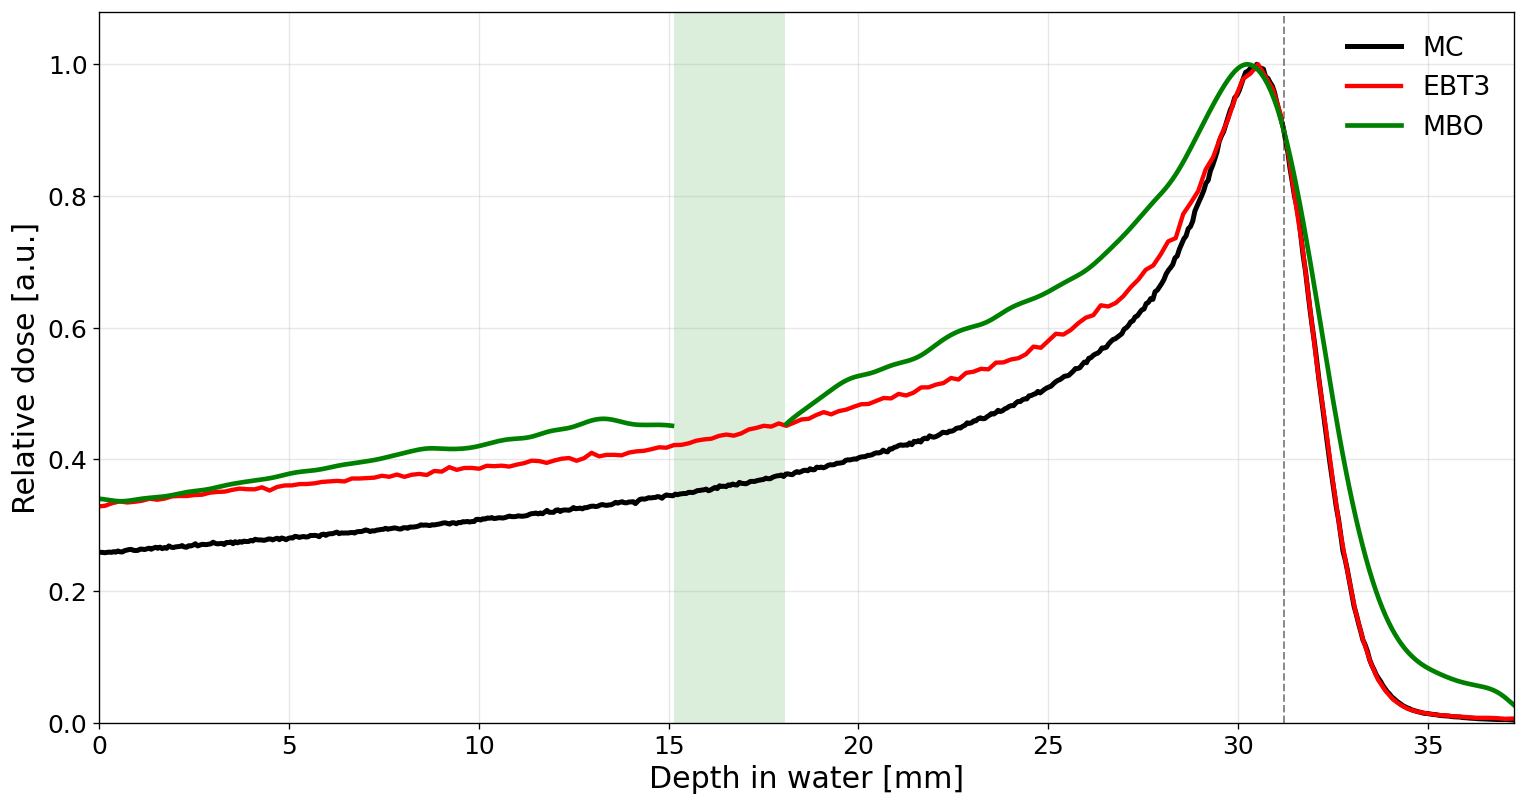

Loaded MC points:   640 from /home/leszekgrzanka/workspace/osl_mb_foils/notebooks/pub_something_2026/mc/mc_ccb_big.csv
Loaded EBT3 points: 264 from /home/leszekgrzanka/workspace/osl_mb_foils/notebooks/pub_something_2026/ebt_foils/ebt_profile_ccb.csv
Loaded MBO points:  507 from /home/leszekgrzanka/workspace/osl_mb_foils/output/pub2026/mbo/data/mbo_profile_ccb.csv
MBO gap points:     34 between 13.0 and 15.5 mm

MC distal 90% point:   26.784 mm (reference)
EBT3 distal 90% point: 26.713 mm -> shift +0.071 mm
MBO distal 90% point:  31.002 mm -> shift -4.218 mm


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repository root from current working directory.
repo_root = Path.cwd()
if not (repo_root / "notebooks" / "pub_something_2026").exists():
    for parent in repo_root.parents:
        if (parent / "notebooks" / "pub_something_2026").exists():
            repo_root = parent
            break

data_root = repo_root / "notebooks" / "pub_something_2026"
# Prefer the freshly produced MBO profile from the CLI pipeline
# (`poetry run python -m src.pub2026.cli run ...`); fall back to the
# notebook-local cached copy in `mbo_foils/`.
mbo_pipeline_dir = repo_root / "output" / "pub2026" / "mbo" / "data"

mc_file = data_root / "mc" / "mc_ccb_big.csv"
ebt_file = data_root / "ebt_foils" / "ebt_profile_ccb.csv"
mbo_pipeline_file = mbo_pipeline_dir / "mbo_profile_ccb.csv"
mbo_local_file = data_root / "mbo_foils" / "mbo_profile_ccb.csv"
mbo_file = mbo_pipeline_file if mbo_pipeline_file.exists() else mbo_local_file

# Configurable exclusion window for the plotted MBO curve after alignment.
MBO_EXCLUDE_MIN_MM = 13.0
MBO_EXCLUDE_MAX_MM = 15.5
WATER_EQ_FACTOR = 1.165
BUMP_BAND_ALPHA = 0.14

for f in (mc_file, ebt_file, mbo_file):
    if not f.exists():
        raise FileNotFoundError(f"Missing input file: {f}")

mc = pd.read_csv(mc_file).rename(columns={"depth": "x_mm", "dose": "dose_Gy"})
ebt = pd.read_csv(ebt_file)
mbo = pd.read_csv(mbo_file)

def prepare_profile(df):
    profile = df[["x_mm", "dose_Gy"]].copy().sort_values("x_mm").reset_index(drop=True)
    profile["relative_dose"] = profile["dose_Gy"] / profile["dose_Gy"].max()
    return profile

def distal_falloff_point(profile, level=0.9):
    x = profile["x_mm"].to_numpy()
    y = profile["relative_dose"].to_numpy()

    peak_idx = y.argmax()
    for idx in range(peak_idx + 1, len(y)):
        if y[idx] <= level:
            x0, x1 = x[idx - 1], x[idx]
            y0, y1 = y[idx - 1], y[idx]
            if y1 == y0:
                return x1
            fraction = (level - y0) / (y1 - y0)
            return x0 + fraction * (x1 - x0)

    raise ValueError(f"Could not find distal {level:.0%} falloff point.")

mc = prepare_profile(mc)
ebt = prepare_profile(ebt)
mbo = prepare_profile(mbo)

mc_range_90 = distal_falloff_point(mc, level=0.9)
ebt_range_90 = distal_falloff_point(ebt, level=0.9)
mbo_range_90 = distal_falloff_point(mbo, level=0.9)

ebt_shift = mc_range_90 - ebt_range_90
mbo_shift = mc_range_90 - mbo_range_90

ebt["x_aligned_mm"] = ebt["x_mm"] + ebt_shift
mbo["x_aligned_mm"] = mbo["x_mm"] + mbo_shift
mc["x_aligned_mm"] = mc["x_mm"]

mbo_plot = mbo.copy()
mbo_gap_mask = (mbo_plot["x_aligned_mm"] >= MBO_EXCLUDE_MIN_MM) & (mbo_plot["x_aligned_mm"] <= MBO_EXCLUDE_MAX_MM)
mbo_plot.loc[mbo_gap_mask, "relative_dose"] = float("nan")

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 16,
})

fig, ax = plt.subplots(figsize=(13, 7), dpi=120)

ax.axvspan(MBO_EXCLUDE_MIN_MM, MBO_EXCLUDE_MAX_MM, color="green", alpha=BUMP_BAND_ALPHA, linewidth=0)

ax.plot(mc["x_aligned_mm"], mc["relative_dose"], color="black", linewidth=3.0, label="MC")
ax.plot(ebt["x_aligned_mm"], ebt["relative_dose"], color="red", linewidth=2.6, label="EBT3")
ax.plot(mbo_plot["x_aligned_mm"], mbo_plot["relative_dose"], color="green", linewidth=2.8, label="MBO")

ax.axvline(mc_range_90, color="black", linestyle="--", linewidth=1.2, alpha=0.45)

ax.set_xlabel("X position [mm]")
ax.set_ylabel("Relative dose [a.u.]")
ax.set_xlim(0, 32)
ax.set_ylim(0, 1.08)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

mc["x_water_mm"] = mc["x_aligned_mm"] * WATER_EQ_FACTOR
ebt["x_water_mm"] = ebt["x_aligned_mm"] * WATER_EQ_FACTOR
mbo_plot["x_water_mm"] = mbo_plot["x_aligned_mm"] * WATER_EQ_FACTOR
mc_range_90_water = mc_range_90 * WATER_EQ_FACTOR

fig, ax = plt.subplots(figsize=(13, 7), dpi=120)

ax.axvspan(MBO_EXCLUDE_MIN_MM * WATER_EQ_FACTOR, MBO_EXCLUDE_MAX_MM * WATER_EQ_FACTOR, color="green", alpha=BUMP_BAND_ALPHA, linewidth=0)

ax.plot(mc["x_water_mm"], mc["relative_dose"], color="black", linewidth=3.0, label="MC")
ax.plot(ebt["x_water_mm"], ebt["relative_dose"], color="red", linewidth=2.6, label="EBT3")
ax.plot(mbo_plot["x_water_mm"], mbo_plot["relative_dose"], color="green", linewidth=2.8, label="MBO")

ax.axvline(mc_range_90_water, color="black", linestyle="--", linewidth=1.2, alpha=0.45)

ax.set_xlabel("Depth in water [mm]")
ax.set_ylabel("Relative dose [a.u.]")
ax.set_xlim(0, 32 * WATER_EQ_FACTOR)
ax.set_ylim(0, 1.08)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Loaded MC points:   {len(mc)} from {mc_file}")
print(f"Loaded EBT3 points: {len(ebt)} from {ebt_file}")
print(f"Loaded MBO points:  {len(mbo)} from {mbo_file}")
print(f"MBO gap points:     {int(mbo_gap_mask.sum())} between {MBO_EXCLUDE_MIN_MM:.1f} and {MBO_EXCLUDE_MAX_MM:.1f} mm")
print()
print(f"MC distal 90% point:   {mc_range_90:.3f} mm (reference)")
print(f"EBT3 distal 90% point: {ebt_range_90:.3f} mm -> shift {ebt_shift:+.3f} mm")
print(f"MBO distal 90% point:  {mbo_range_90:.3f} mm -> shift {mbo_shift:+.3f} mm")


In [2]:
import numpy as np
from IPython.display import Markdown, display

# Plateau region (in aligned mm) used to compute the Bragg peak-to-plateau ratio.
PLATEAU_MIN_MM = 2.0
PLATEAU_MAX_MM = 8.0


def _distal_level_x(x, y, level):
    """x at which y drops to *level* on the distal side of the peak."""
    peak_idx = int(np.nanargmax(y))
    for i in range(peak_idx + 1, len(y)):
        if y[i] <= level:
            x0, x1 = x[i - 1], x[i]
            y0, y1 = y[i - 1], y[i]
            if y1 == y0:
                return float(x1)
            return float(x0 + (level - y0) / (y1 - y0) * (x1 - x0))
    return float("nan")


def _proximal_level_x(x, y, level):
    """x at which y rises to *level* on the proximal side of the peak."""
    peak_idx = int(np.nanargmax(y))
    for i in range(peak_idx, 0, -1):
        if y[i - 1] <= level:
            x0, x1 = x[i - 1], x[i]
            y0, y1 = y[i - 1], y[i]
            if y1 == y0:
                return float(x0)
            return float(x0 + (level - y0) / (y1 - y0) * (x1 - x0))
    return float("nan")


def profile_metrics(x_mm, y_rel, plateau_min_mm, plateau_max_mm):
    x = np.asarray(x_mm, dtype=float)
    y = np.asarray(y_rel, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite], y[finite]
    order = np.argsort(x)
    x, y = x[order], y[order]

    d80 = _distal_level_x(x, y, 0.80)
    d50 = _distal_level_x(x, y, 0.50)
    d20 = _distal_level_x(x, y, 0.20)
    p50 = _proximal_level_x(x, y, 0.50)

    plateau_mask = (x >= plateau_min_mm) & (x <= plateau_max_mm)
    plateau = float(np.nanmean(y[plateau_mask])) if plateau_mask.any() else float("nan")
    peak = float(np.nanmax(y))

    return {
        "Distal fall-off 80%-20% [mm]": d20 - d80,
        "Peak width FWHM [mm]": d50 - p50,
        "Peak/Plateau ratio": (peak / plateau) if plateau > 0 else float("nan"),
    }


def _df_to_markdown(df, floatfmt=".3f"):
    cols = list(df.columns)
    header = "| " + df.index.name + " | " + " | ".join(cols) + " |"
    sep = "|" + "|".join(["---"] * (len(cols) + 1)) + "|"
    rows = [
        "| " + str(idx) + " | "
        + " | ".join(format(row[c], floatfmt) for c in cols) + " |"
        for idx, row in df.iterrows()
    ]
    return "\n".join([header, sep, *rows])


# Use the original (non-gapped) MBO data so peak detection is unaffected by
# the NaN exclusion window applied for plotting.
metrics_records = {
    "MC":   profile_metrics(mc["x_aligned_mm"],  mc["relative_dose"],  PLATEAU_MIN_MM, PLATEAU_MAX_MM),
    "EBT3": profile_metrics(ebt["x_aligned_mm"], ebt["relative_dose"], PLATEAU_MIN_MM, PLATEAU_MAX_MM),
    "MBO":  profile_metrics(mbo["x_aligned_mm"], mbo["relative_dose"], PLATEAU_MIN_MM, PLATEAU_MAX_MM),
}
metrics_df = pd.DataFrame(metrics_records).T
metrics_df.index.name = "Profile"

print(f"Plateau region used for peak/plateau ratio: "
      f"{PLATEAU_MIN_MM:.1f}-{PLATEAU_MAX_MM:.1f} mm (aligned coordinates)")
print()
print("CCB profile metrics:")
print(metrics_df.to_string(float_format=lambda v: f"{v:8.3f}"))

display(Markdown("### CCB profile metrics\n\n" + _df_to_markdown(metrics_df)))


Plateau region used for peak/plateau ratio: 2.0-8.0 mm (aligned coordinates)

CCB profile metrics:
         Distal fall-off 80%-20% [mm]  Peak width FWHM [mm]  Peak/Plateau ratio
Profile                                                                        
MC                              1.282                 6.442               3.506
EBT3                            1.286                 9.259               2.741
MBO                             1.757                11.430               2.592


### CCB profile metrics

| Profile | Distal fall-off 80%-20% [mm] | Peak width FWHM [mm] | Peak/Plateau ratio |
|---|---|---|---|
| MC | 1.282 | 6.442 | 3.506 |
| EBT3 | 1.286 | 9.259 | 2.741 |
| MBO | 1.757 | 11.430 | 2.592 |